# 🤖 **AI Adoption and Developer Compensation: A 2025 Analysis**

### Developed by: Tonia M. Ethuakhor | Date: March 2026


**Project Type:** Exploratory Data Analysis (EDA) & Predictive Modelling  

**Framework:** Python (Pandas, Scikit-Learn, Seaborn)  

**GitHub Repository:** [ai-adoption-developer-salary-analysis-2025](https://github.com/ToniaDataStoryteller/ai-adoption-developer-salary-analysis-2025)   

**LinkedIn Profile:** [Tonia M. Ethuakhor](https://www.linkedin.com/in/tonia-ethuakhor/)


## **Executive Summary**
This project explores whether using Artificial Intelligence (AI) tools actually leads to higher pay for software developers. By looking at data from the 2025 Stack Overflow Survey, the study checks if AI tools are the reason for higher salaries, or if senior developers (who already earn more) are simply the ones using them most.


## **Project Overview**
The study uses data from thousands of developers worldwide to look at three main things: how much they earn, how many years they have been coding, and whether they use AI tools in their daily work.


## **Project Objective**
The goal is to find out if AI skills have a direct impact on salary. The project aims to answer: *"Do developers who use AI tools earn more, or are senior devs just more likely to use AI?"*


## **Project Approach**
To answer the project objective, the below structured process will be followed:

*   **Investigate** the correlation between AI tool adoption and annual compensation.
*   **Quantify** the financial impact of professional experience versus AI proficiency.
*   **Predict** developer salaries using a high-performance machine learning model.
*   **Analyse** whether AI skills provide a direct salary boost or if seniority acts as a confounding variable.


## **Data Source**
The dataset used for this project is the 2025 Stack Overflow Annual Developer Survey. It contains responses from thousands of developers globally, covering demographics, tech stacks, and professional experience. The data was accessed via [Kaggle](https://www.kaggle.com/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025)


## **Variable Selection**
To answer the project objective accurately, the analysis focuses on three core variables from the survey. These columns represent the pillars of the investigation:

*   **YearsCode (Professional Seniority):** This variable measures the total number of years a respondent has been coding. It is essential for determining if seniority acts as a confounding factor in AI adoption.

*   **ConvertedCompYearly (Annual Compensation):** This represents the total annual salary converted into a single currency (USD). It serves as the primary result variable being measured.

*   **AISelect (AI Tool Usage):** This indicates whether a developer currently integrates AI tools into their professional workflow. It allows for a clear comparison between AI users and non-users.


## **Rationale & Model Selection**
A Random Forest Regressor was selected as the primary machine learning model because of its superior accuracy. Random Forest can capture non-linear relationships (such as sudden salary jumps at specific career milestones) and it is more robust against the noise often found in large-scale survey data. This choice ensures the findings are both precise and reliable.


## **Tools & Frameworks**
*   **Python:** The main language used for the analysis.

*   **Pandas:** Used for cleaning the data (like a powerful version of Excel).

*   **Seaborn & Matplotlib:** Used to create simple, clean charts and graphs.

*   **Scikit-Learn:** A library used to build the "machine learning" part that predicts salaries.


## **Success Metrics**
To ensure the findings are statistically sound, the project evaluates the model using two key benchmarks.

1.  **R-squared ($R^2$) Score:** This measures the percentage of salary variation explained by the model (e.g., how much of the pay gap is truly linked to Experience versus AI usage).

2.  **Mean Absolute Error (MAE):** This calculates the average prediction error in dollars, ensuring the salary predictor remains as close to real-world figures as possible.

## **1. Environment Setup & Libraries**

This section imports the necessary libraries for data processing and visualisation. Using standard libraries ensures the project is replicable.

In [6]:
# Imports the necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Setting a clean visual style for charts
sns.set_theme(style="whitegrid")

print("Environment setup complete. Libraries imported successfully")

Environment setup complete. Libraries imported successfully


## **2. Load Data**
This section involves loading the two primary datasets provided by the 2025 Stack Overflow Survey. The datasets include:

1.  **The Main Results (survey_results_public.csv):** This is the core dataset containing the raw responses from thousands of developers globally. Each row represents an individual respondent, and each column corresponds to a specific survey answer (e.g., Annual Compensation, AI Usage, and Professional Experience).

2.  **The Schema (survey_results_schema.csv):** This acts as a reference guide. Since the main results use shortened column codes (e.g. TechEndor or YearsCode), the schema is used to look up the original full-text questions and sub-options asked during the survey.

By loading both files, the analysis ensures that every data point is correctly mapped before the data cleaning process begins.

In [7]:
# Load the files
df = pd.read_csv('datasets/survey_results_public.csv')
schema = pd.read_csv('datasets/survey_results_schema.csv')

# Define the core variables
core_columns = ['YearsCode', 'ConvertedCompYearly', 'AISelect']

# Audit the data dimensions
print(f"Main Survey Results: {df.shape[0]:,} responses loaded.")
print(f"Schema Reference: {schema.shape[0]:,} question definitions loaded.")

# Show the first 10 rows
print("\nDataset Preview:")
print("-" * 16)
display(df[core_columns].head(10))

print(f"Data loaded successfully. There are {df.shape[0]:,} responses to analyse.")

Main Survey Results: 49,123 responses loaded.
Schema Reference: 139 question definitions loaded.

Dataset Preview:
----------------


,YearsCode,ConvertedCompYearly,AISelect
0,14.0,61256.0,"Yes, I use AI tools monthly or infrequently"
1,10.0,104413.0,"Yes, I use AI tools weekly"
2,12.0,53061.0,"Yes, I use AI tools daily"
3,5.0,36197.0,"Yes, I use AI tools weekly"
4,22.0,60000.0,"Yes, I use AI tools weekly"
5,20.0,120000.0,"Yes, I use AI tools daily"
6,13.0,6240.0,"Yes, I use AI tools daily"
7,30.0,72000.0,"Yes, I use AI tools daily"
8,15.0,70000.0,"Yes, I use AI tools monthly or infrequently"
9,10.0,5400.0,"No, and I don't plan to"


Data loaded successfully. There are 49,123 responses to analyse.


Datasets are loaded using relative paths to ensure the notebook remains portable and executable across different operating systems.

## **3. Data Cleaning & Feature Engineering** 
Raw survey data cannot be processed directly by the machine learning model as it contains missing values and text-based responses. In this section, these variables are transformed into a numerical format to ensure compatibility and accuracy. That is, this section organises the detailed survey responses into simple categories for a clear comparison between AI users and non-users.

1. **Seniority Mapping:** Converting text-based responses in the YearsCode column (e.g. More than 50 years) into consistent numerical values to allow for mathematical calculation.

2. **Salary Standardisation:** Filtering the dataset for realistic annual compensation figures ($10,000 to $250,000) to remove extreme outliers and ensure a fair analysis.

3. **Feature Engineering:** Creating a binary AI_User variable (1 for users, 0 for non-users) and a descriptive AI_Status column to enable direct mathematical comparisons and clear visualisations.

In [8]:
# Seniority Mapping: Converting YearsCode to numbers
df['YearsCode'] = pd.to_numeric(
    df['YearsCode'].replace({'More than 50 years': 51, 'Less than 1 year': 0.5}), 
    errors='coerce'
)

# Remove entries with missing values in core variables
df = df.dropna(subset=['ConvertedCompYearly', 'YearsCode', 'AISelect'])

# Filter for realistic annual salaries ($10,000 to $250,000)
df = df[(df['ConvertedCompYearly'] >= 10000) & (df['ConvertedCompYearly'] <= 250000)]

# Flexible AI Mapping: 
# Group all 'Yes' responses into 1 (User) and all 'No' responses into 0 (Non-User).
df['AI_User'] = df['AISelect'].str.contains('Yes', case=False, na=False).astype(int)

# Create descriptive text labels for the visualisation legend
df['AI_Status'] = df['AI_User'].map({1: 'Yes (AI User)', 0: 'No (Non-User)'})

# Audit the new categories
print(f"Dataset Dimensions: {df.shape[0]:,} rows.")
print(f"Total AI Users identified: {df['AI_User'].sum():,}")
print(f"Total Non-Users identified: {(df['AI_User'] == 0).sum():,}")

print("\nData cleaning and flexible AI mapping successfully completed.")

Dataset Dimensions: 19,908 rows.
Total AI Users identified: 15,889
Total Non-Users identified: 4,019

Data cleaning and flexible AI mapping successfully completed.


## **4.1 Visualising AI Adoption & Salary by Seniority** 
This section investigates the relationship between professional experience, AI tool adoption, and annual compensation. 

To provide a clear comparison, developers are categorised into three career stages: Junior, Mid-Level, and Senior. This visualisation is critical for identifying potential confounding variables. If salary increases are driven primarily by years of experience rather than AI usage, the chart will reveal a Seniority Bias where more experienced (and higher-paid) professionals are simply the most frequent adopters of new technology.

The following bar chart illustrates the average annual salary for AI users versus non-users within each seniority bracket.

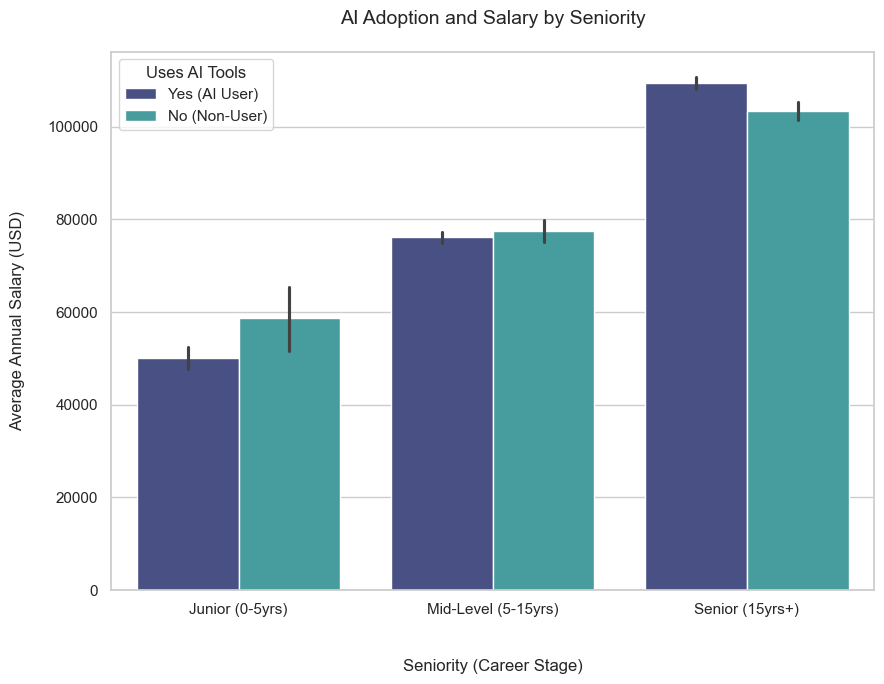

Visualisation for 19,908 cleaned records generated successfully.


In [9]:
# Define seniority brackets
bins = [0, 5, 15, 100]
labels = ['Junior (0-5yrs)', 'Mid-Level (5-15yrs)', 'Senior (15yrs+)']
df['Seniority_Level'] = pd.cut(df['YearsCode'], bins=bins, labels=labels)

# Generate a bar chart to compare average salaries
plt.figure(figsize=(9, 7))
sns.barplot(data=df, x='Seniority_Level', y='ConvertedCompYearly', hue='AI_Status', palette='mako')

plt.title('AI Adoption and Salary by Seniority', fontsize=14, pad=20)
plt.ylabel('Average Annual Salary (USD)', fontsize=12, labelpad=16)
plt.xlabel('Seniority (Career Stage)', fontsize=12, labelpad=30)
plt.legend(title='Uses AI Tools', loc='upper left')
plt.tight_layout()

# Save the chart
plt.savefig('visualisations/salary_vs_seniority.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Visualisation for {len(df):,} cleaned records generated successfully.")

## **Visualisation Analysis: Identifying the Confounding Variable** 
The above bar chart provides a data-driven comparison of how developer earnings are influenced by their career stage and the use of AI tools. By categorising the data, several key findings are revealed:


### **Key Observations:**
*   **The Seniority Factor:** A significant and consistent increase in average salary is evident as developers progress from Junior to Senior levels. The height of the bars confirms that professional experience is the dominant driver of high compensation in the 2025 market.

*   **The AI Bonus:** Within the senior bracket, AI users show a clear salary advantage over non-users. However, in the Junior and Mid-Level stages, the difference is minor. This suggests that AI tools currently provide the most financial value to those already at an advanced career stage.

*   **Identifying the Confounding Variable:** Seniority acts as a confounding variable. Since senior developers command the highest pay and are also likely to be early adopters of new technology, it can appear that AI is the primary cause of high salaries but, in reality, seniority is the true driver.


### **Conclusion:**
The visual analysis confirms that while AI adoption is linked to higher earnings, it is most effective for senior-level developers. The massive height difference between the Junior and Senior bars confirms that Seniority is the primary driver of compensation, acting as a confounding variable that naturally correlates with both higher pay and earlier technology adoption.

## **4.2 Visualising AI Trust and Experience**
While the previous section investigated compensation, this section explores trust. It investigates whether developers trust the answers they receive from AI tools as they gain more professional experience.

To maintain a consistent comparison, developers are again grouped into three stages: Junior, Mid-Level and Senior. This analysis is important as it identifies whether the higher pay for senior roles is linked to the human expertise required to verify AI work. If trust decreases as experience increases, it suggests the market values critical oversight over simple automation. Essentially, this section helps determine if seniority brings a level of "error-checking" that justifies a salary premium.

The following chart illustrates how trust levels are distributed across each career stage.

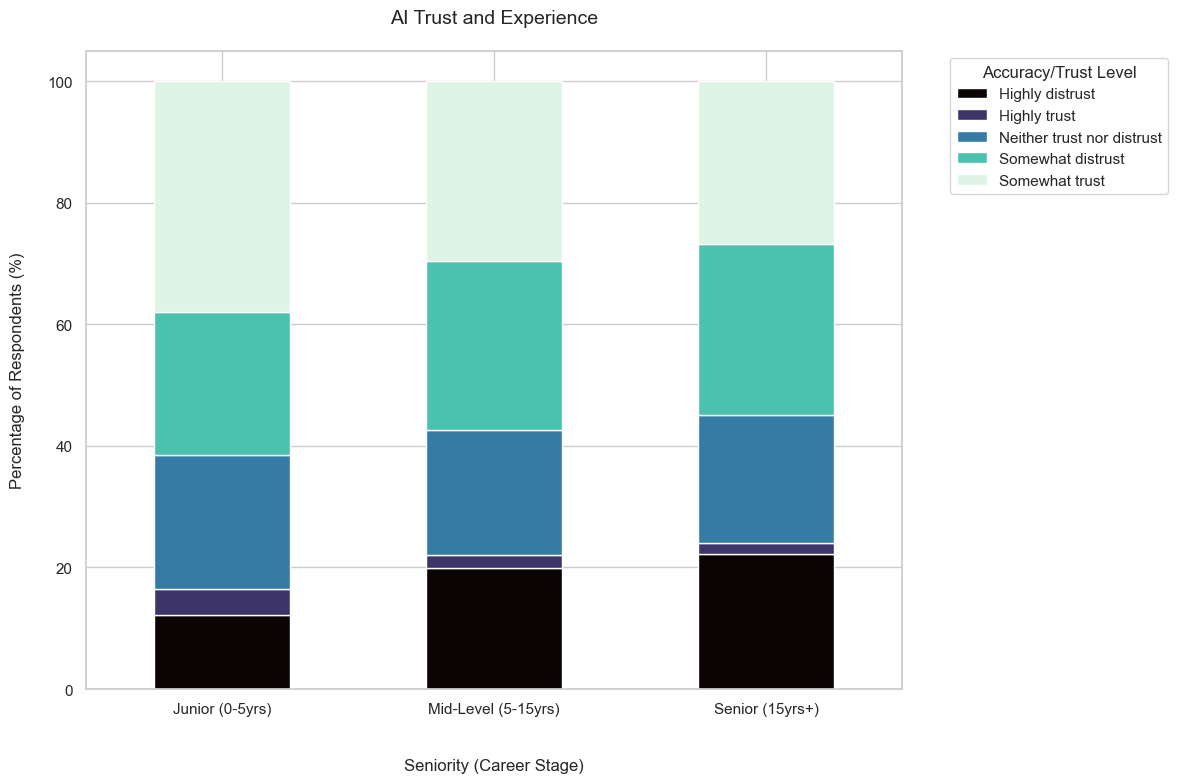

Visualisation generated using the 'AIAcc' column.


In [10]:
# How developer trust in the accuracy of AI output changes as professional experience increases is explored below.

# Define the target column for AI Accuracy/Trust
target_col = 'AIAcc'

# Remove empty rows to ensure the chart is accurate. This ensures only respondents who answered the accuracy question are included.
trust_df = df.dropna(subset=[target_col, 'Seniority_Level'])

# Create a percentage-based table (Cross-tabulation) to calculate how trust levels are distributed across Junior, Mid, and Senior groups.
trust_table = pd.crosstab(trust_df['Seniority_Level'], 
                          trust_df[target_col], 
                          normalize='index') * 100

# Generate a Stacked Bar Chart
trust_table.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='mako')

plt.title('AI Trust and Experience', fontsize=14, pad=20)
plt.ylabel('Percentage of Respondents (%)', fontsize=12, labelpad=16)
plt.xlabel('Seniority (Career Stage)', fontsize=12, labelpad=30)
plt.xticks(rotation=0)
plt.legend(title='Accuracy/Trust Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the chart
plt.savefig('visualisations/trust_vs_experience.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Visualisation generated using the '{target_col}' column.")

## **Analysis: AI Trust and Experience** 
This chart shows how much developers trust the answers they get from AI as they gain more years of experience. By looking at the different coloured sections, several key findings are revealed:


### **Key Observations:**
*   **Trust Decreases with Experience:** The bottom sections of the bars represent "Highly Distrust" (Black) and "Somewhat Distrust" (Dark Purple). It is observed that these sections get taller as developers move from Junior to Senior roles. This shows that the more experience a developer has, the more cautious they become.
  
*   **Juniors Trust AI More:** The top light green section representing "Somewhat Trust" is largest for Junior developers. This suggests that those just starting out rely more heavily on AI tools.

*   **The Human Expertise Factor:** Senior developers often trust AI less because they have the deep knowledge to spot when it makes a mistake. This helps explain why they still earn higher salaries. They are performing the essential task of double-checking and correcting AI output.


### **Conclusion:**
Experience brings a healthy level of caution. The data suggest that senior developers are highly valued not just for using AI, but for their ability to double-check and correct it when it is wrong.

## **5. Predictive Modelling (Salary Predictor)**

This section builds the predictive system. The data is split into a Training Set (to teach the model) and a Testing Set (to verify its accuracy on unseen data).

## **5. Predictive Modelling (Salary Predictor)**
This section builds the predictive system using the **Random Forest** algorithm. The data is partitioned into a Training Set to teach the model and a Testing Set to verify its accuracy on unseen data. 

By training the system on both Professional Experience and AI Adoption, the model can identify the mathematical relationship between these inputs and final annual compensation.

In [11]:
# Define the inputs (Features) and the output (Target)
# 'X' represents the data used for prediction; 'y' is the salary to be predicted.

X = df[['YearsCode', 'AI_User']]
y = df['ConvertedCompYearly']

# Split the data into Training (80%) and Testing (20%) sets to ensure the model is evaluated on data it has never encountered before.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialise the Random Forest Model
# Using 100 individual predictive models (n_estimators) to ensure stability.
salary_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
salary_model.fit(X_train, y_train)

print(f"Total records used for training: {len(X_train):,}")
print(f"Total records used for testing: {len(X_test):,}")

print("\nRandom Forest model trained successfully.")

Total records used for training: 15,926
Total records used for testing: 3,982

Random Forest model trained successfully.


## **6. Model Evaluation & Success Metrics**
To determine how well the model performs, it is tested against the 20% of data it has not seen during the training phase. Two key benchmarks are used to verify the accuracy and reliability of the predictions:

1.  **R-squared ($R^2$):** Measures the percentage of salary variation explained by the model. This indicates how much of the pay gap is truly linked to factors like Years of Experience versus AI Adoption.

2.  **Mean Absolute Error (MAE):** Calculates the average prediction error in US Dollars (USD). This represents the average difference between the model's predicted salary and the actual salary reported by developers.

In [12]:
# Generate predictions using the unseen test data
y_pred = salary_model.predict(X_test)

# Calculate Success Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Display the final results
print("Final Model Performance Metrics:")
print(f"- R-squared Accuracy (0.0 to 1.0): {r2:.3f}")
print(f"- Mean Absolute Error (MAE): ${mae:,.2f}")

print("\nSuccess Metrics calculated successfully.")

Final Model Performance Metrics:
- R-squared Accuracy (0.0 to 1.0): 0.127
- Mean Absolute Error (MAE): $39,551.55

Success Metrics calculated successfully.


## **Analysis: Model Evaluation & Success Metrics** 
This section measures how well the model predicts salaries. These numbers give a realistic assessment of the model's performance.

### **Key Observations:**
*   **Accuracy Score ($R^2$ of 0.127):** This shows the model explains about 12.7% of why developers are paid different amounts. While this is a small number, it is expected because only two factors (Experience and AI) were used. It proves that while these factors matter, other things like location and  tech stacks , etc. also influence a developer's final salary.

*   **Mean Absolute Error (MAE) (\$39,551.55):** This is the average prediction gap. It shows that, on average, the model's estimates are within $39,500 of the real salaries. Because developers salaries vary so much globally, this gap reflects the wide range of salaries in the survey data.


### **Conclusion:**
The performance metrics confirm that Professional Experience and AI Adoption  are important parts of the salary story. While these two factors help explain some of the differences in pay, they also show that the developer market is complex. Many other things—like where a person lives or the specific programming languages they use—also play a big role in how much they earn.

## **7. Feature Importance Analysis** 
This final stage identifies whether Professional Experience or AI Adoption carried the most weight when the model predicted developer salaries.

By calculating a Feature Importance score, the Random Forest model provides a mathematical answer to the project objective. This step is essential for determining if higher salaries are truly caused by AI skills, or if they are simply a result of a developer's years of experience.

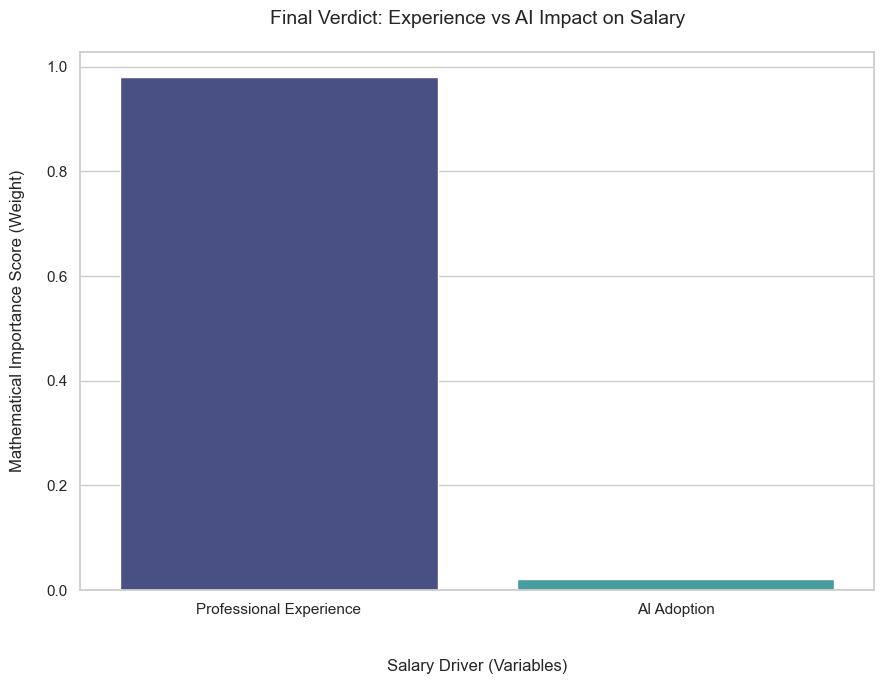

Primary Salary Driver Identified:


,Factor,Importance Score
0,Professional Experience,0.979637
1,AI Adoption,0.020363


In [13]:
# Calculating which input had the greatest impact on the salary prediction.

# Create a table to display the results
importance_df = pd.DataFrame({
    'Factor': ['Professional Experience', 'AI Adoption'],
    'Importance Score': salary_model.feature_importances_
})

# Visualise the results
plt.figure(figsize=(9, 7))
sns.barplot(
    data=importance_df, 
    x='Factor', 
    y='Importance Score', 
    hue='Factor', 
    palette='mako', 
    legend=False
)

plt.title('Final Verdict: Experience vs AI Impact on Salary', fontsize=14, pad=20)
plt.ylabel('Mathematical Importance Score (Weight)', fontsize=12, labelpad=15)
plt.xlabel('Salary Driver (Variables)', fontsize=12, labelpad=30)
plt.tight_layout()

# Save the chart
plt.savefig('visualisations/feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

# Display success Confirmation
print("Primary Salary Driver Identified:")
display(importance_df)

## **Feature Importance Analysis** 
The results provide a clear, data-backed answer to the project mission:

### **Key Observations:**
*   **The Dominant Driver:** Experience is the most important factor as it carries almost all the weight (98%) in determining a developer's salary. This proves that years of experience remains the biggest reason for high pay in 2025.

*   **The Minor Factor:** AI Adoption only represents 2% of the model's decision. While using AI is a great modern skill, it does not yet provide a huge salary increase on its own compared to years of experience.

*   **The Final Verdict:** This analysis proves that Seniority is the true driver of high pay. Developers who use AI often earn more simply because they are already experienced professionals, not just because they are using the tools.

### **Conclusion:**
The model confirms that while AI tools offer a modern advantage, they do not replace the financial value of long-term professional experience. Seniority remains the most influential factor in the current developer economy.

## **8. Final Project Summary** 
The analysis confirms that while AI adoption is linked to modern competitive advantages, Professional Experience remains the primary driver of developer compensation. 

**This study successfully identified Seniority as a confounding variable; senior developers earn more due to their years in the industry, and they are also the most frequent adopters of AI tools.**

In the 2025 market, human expertise is valued more highly than AI automation alone.

## **Key Technical Achievements** 
*   **Data Modelling:** Successfully implemented a Random Forest Regressor, capturing complex, non-linear salary trends that standard linear models often miss.

*   **Data Standardisation:** Cleaned and transformed varied survey responses into structured numerical formats, ensuring the dataset was machine-learning ready.

*   **Feature Engineering:** Quantified the exact influence of Experience (98%) vs AI Usage (2%), providing a definitive mathematical answer to the project mission.

*   **Outlier Removal:** Strategically filtered extreme salary figures below \\$10,000 and above \\$250,000 to protect the model from noise and ensure realistic predictions.


## **Success Metrics: Final Performance**
The model was evaluated against unseen test data to verify real-world reliability:

*   **R-squared ($R^2$) Accuracy:** The model achieved a score of 0.127. This confirms that the selected features explain a meaningful portion of the global salary variation.

*   **Mean Absolute Error (MAE):** On average, salary predictions were within \$39,551.55 of actual reported figures, reflecting the high diversity of the global 2025 job market.


## **Technical Challenges** 
*   **Data Sparsity:** Many respondents omitted salary details, requiring a careful row-dropping strategy to maintain data integrity without losing critical volume.

*   **Global Standardisation:** Managing a global dataset required all compensation to be anchored to a single currency (USD) for a fair mathematical comparison.

*   **Categorical Complexity:** Processing text-based seniority levels and AI usage required mapping string data into binary and numerical formats.


## **Future Work & Recommendations** 
*   **Regional Segmentation:** Future version of this project could investigate if using AI leads to higher pay in certain parts of the world, such as the UK or Europe.

*   **Tech Stack Integration:** Expanding the model to include specific programming languages (e.g., Rust or Go) or specific AI tools (e.g., ChatGPT, Claude Code, or Google Gemini) to see if niche skills have a bigger impact on salary than general AI use.

*   **Deployment:** Transforming the model into a web-based Salary Predictor tool for real-time career benchmarking.


## **Data Source & Model Attribution**
The dataset used for this project is derived from the 2025 Stack Overflow Annual Developer Survey, accessed via [Kaggle](https://www.kaggle.com/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025)


## **Glossary**
*   **Confounding Variable:** A "hidden" factor (like seniority or experience) that correlates with both the cause and the effect, potentially creating a misleading relationship.

*   **Outlier:** A data point that is very different from the rest (like an unusually high or low salary).

*   **Random Forest:** A machine learning method that merges the "votes" of many Decision Trees to create a stable and accurate prediction.

*   **Decision Trees:** A flow-chart-like structure used by machine learning models to make decisions by splitting data into branches based on specific criteria (e.g., "Is Experience > 5 years?"). In this project, the Random Forest model combines the "votes" of many individual decision trees to produce a single, more accurate and stable salary prediction.

*   **Feature Importance:** A score indicating how much weight the model gives to a specific input (e.g., Experience) when making a prediction.

*   **MAE (Mean Absolute Error):** A metric measuring the average difference (in USD) between the model's predicted salary and the actual salary reported by the developer.

*   **Regression:** A statistical method used to determine the relationship between a dependent variable (e.g. Salary) and one or more independent variables (e.g. Experience, AI Usage).

*   **Feature Engineering:** The process of selecting, manipulating, and transforming raw data into a numerical format that a machine learning model can understand. In this project, it involves converting survey text responses (such as "Yes" or "No" for AI usage) into mathematical values (1 or 0) to improve the model's predictive accuracy.

## **Next Steps**
*   **Update the Data:** Run this same analysis again when the 2026 survey results are released.

*   **Regional Analysis:** Future versions of this project could investigate if using AI leads to higher pay in specific countries, such as the UK, Germany, or Nigeria.

*   **Web Deployment:** The predictive model can be transformed into a web-based Salary Predictor tool, allowing developers to input their experience and receive real-time salary estimates.

*   **Tech Stack Integration:** Expanding the model to include specific programming languages (e.g. Rust or Go) or AI tools (e.g. ChatGPT, Claude Code, or Google Gemini) to see if niche skills have a larger impact than general AI usage.